In [1]:
import json
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [2]:
data_dir = Path("../data/bigobench")

# Загрузка splits
def load_jsonl(filepath):
    """Загрузка JSONL файла"""
    samples = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            samples.append(json.loads(line))
    return samples

train_data = load_jsonl(data_dir / "train.jsonl")
val_data = load_jsonl(data_dir / "val.jsonl")
test_data = load_jsonl(data_dir / "test.jsonl")

# Загрузка метаданных
with open(data_dir / "metadata.json", 'r') as f:
    metadata = json.load(f)

print(f"Train: {len(train_data):,} образцов")
print(f"Val:   {len(val_data):,} образцов")
print(f"Test:  {len(test_data):,} образцов")
print(f"\nВсего: {len(train_data) + len(val_data) + len(test_data):,} образцов")

Train: 732,351 образцов
Val:   159,857 образцов
Test:  143,876 образцов

Всего: 1,036,084 образцов


In [3]:
all_data = train_data + val_data + test_data

# Уникальные задачи
unique_problems = len(set(s['problem_id'] for s in all_data))


# Уникальные классы сложности
unique_time_classes = len(set(s['time_complexity'] for s in all_data))
unique_time_classes_full = set(s['time_complexity'] for s in all_data)
unique_space_classes = len(set(s['space_complexity'] for s in all_data))
unique_space_classes_full = set(s['space_complexity'] for s in all_data)

# Длина кода
code_lengths = [len(s['code']) for s in all_data]

print(f"{'='*60}")
print("ОБЩАЯ СТАТИСТИКА")
print(f"{'='*60}")
print(f"Уникальных задач: {unique_problems:,}")
print(f"Среднее решений на задачу: {len(all_data) / unique_problems:.1f}")
print(f"\nКлассов временной сложности: {unique_time_classes}")
print(f"Классов пространственной сложности: {unique_space_classes}")
print(f"\nДлина кода (символов):")
print(f"  Мин:     {min(code_lengths):,}")
print(f"  Медиана: {sorted(code_lengths)[len(code_lengths)//2]:,}")
print(f"  Макс:    {max(code_lengths):,}")
print(f"  Средняя: {sum(code_lengths)/len(code_lengths):,.0f}")

ОБЩАЯ СТАТИСТИКА
Уникальных задач: 3,014
Среднее решений на задачу: 343.8

Классов временной сложности: 47
Классов пространственной сложности: 45

Длина кода (символов):
  Мин:     11
  Медиана: 226
  Макс:    65,449
  Средняя: 369


In [18]:
print(unique_time_classes)
print(f"классы временной сложности:\n{unique_time_classes_full}")
print(unique_space_classes)
print(f"классы пространственной сложности:\n{unique_space_classes_full}")

47
классы временной сложности:
{'O(n*logm)', 'O(n*m)', 'O(n+(m+klogk))', 'O((n**2)*m)', 'O(nlogn*m)', 'O((n+m)log(n+m)+k)', 'O(1)', 'O(n+m+k)', 'O(n*(m+k))', 'O(n+m**2)', 'O(n+(m+k))', 'O(n**2+mlogm)', 'O(n**2*mlogm)', 'O(n+m)log(n+m)', 'O((n+m)+k)', 'O(n*(m**2))', 'O(n**2)', 'O(nlogn*mlogm)', 'O(n+mlogm+k)', 'O(n+(m*k))', 'O(nlogn+mlogm)', 'O(n)', 'O(nlogn**2)', 'O(n**2*m**2)', 'O(n**2+m)', 'O(n**2+m**2+k**2)', 'O(n**2*m)', 'O(n+(m+k)log(m+k))', 'O(n*mlogm)', 'O(n+(mlogm+k))', 'O(n+mlogm)', 'O(nlogn+m**2)', 'O((n+m)*k)', 'O(n+m+klogk)', 'O(nlogn+m+k)', 'O(nlogn+mlogm+klogk)', 'O(logn*logm)', 'O(n+m)', 'O(logn)', 'O(nlogn)', 'O(n+(m**2))', 'O(n*m**2)', 'O(n*m*k)', 'O(logn*m)', 'O(nlogn+m)', 'O(n**2+m**2)', 'O(nlogn*m**2)'}
45
классы пространственной сложности:
{'O(n*logm)', 'O(n*m)', 'O((n**2)+m)', 'O(nlogn*m)', 'O(n*logm*logk)', 'O(1)', 'O(n+m+k)', 'O(n+m**2)', 'O(n+(m+k))', 'O(n*logm*k)', 'O(n+m)log(n+m)', 'O((n+m)+k)', 'O(n**2)', 'O(logn*logm*logk)', 'O(n+m+k+l)', 'O(nlogn**2)', 'O(

ТОП-15 КЛАССОВ ВРЕМЕННОЙ СЛОЖНОСТИ
         Класс  Количество  Процент
          O(n)      432302    41.72
          O(1)      231690    22.36
      O(nlogn)      105267    10.16
       O(n**2)       82974     8.01
        O(n*m)       56548     5.46
        O(n+m)       37507     3.62
       O(logn)       19434     1.88
    O(n+mlogm)       10854     1.05
    O(nlogn+m)        9711     0.94
    O(n*mlogm)        9518     0.92
    O(nlogn*m)        8671     0.84
O(nlogn+mlogm)        3349     0.32
O(n+m)log(n+m)        3265     0.32
   O(nlogn**2)        2548     0.25
     O(n+m**2)        2414     0.23


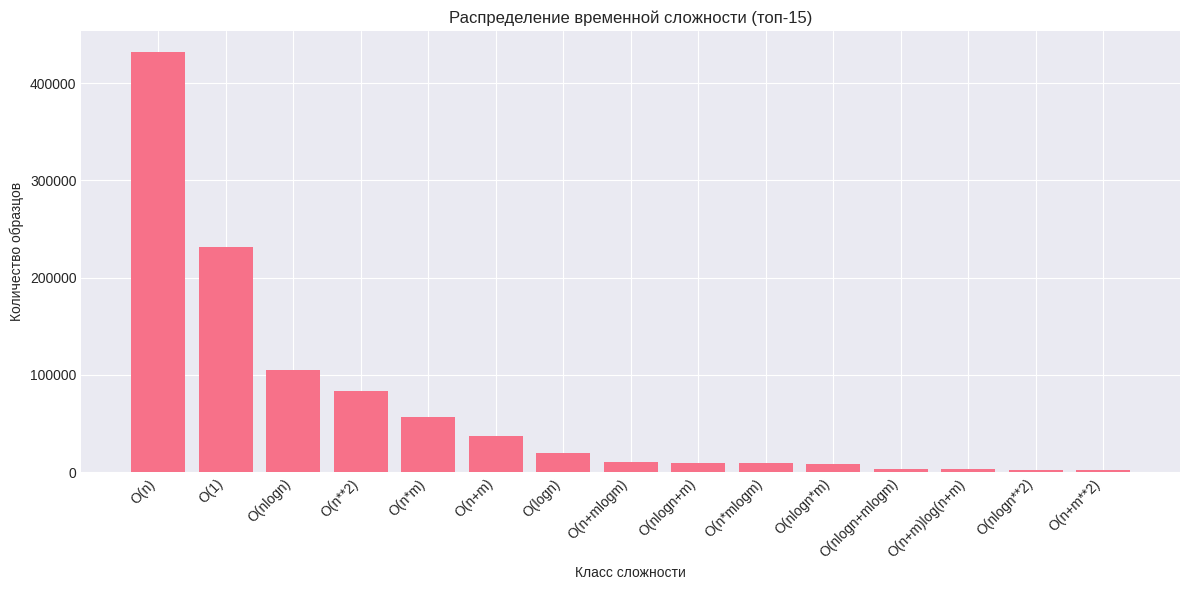

In [ ]:
time_dist = Counter(s['time_complexity'] for s in all_data)

# Топ-15 классов
top_time = time_dist.most_common(15)

df_time = pd.DataFrame(top_time, columns=['Класс', 'Количество'])
df_time['Процент'] = (df_time['Количество'] / len(all_data) * 100).round(2)

print("ТОП-15 КЛАССОВ ВРЕМЕННОЙ СЛОЖНОСТИ")
print(df_time.to_string(index=False))

# Визуализация
plt.figure(figsize=(12, 6))
plt.bar(range(len(df_time)), df_time['Количество'])
plt.xticks(range(len(df_time)), df_time['Класс'], rotation=45, ha='right')
plt.xlabel('Класс сложности')
plt.ylabel('Количество образцов')
plt.title('Распределение временной сложности (топ-15)')
plt.tight_layout()
plt.show()

In [15]:
time_dist = Counter(s['time_complexity'] for s in all_data)

# Топ-15 классов
top_time = time_dist.most_common(550)
df_time_full = pd.DataFrame(top_time, columns=['Класс', 'Количество'])


df_time = pd.DataFrame(top_time, columns=['Класс', 'Количество'])
df_time['Процент'] = (df_time['Количество'] / len(all_data) * 100)#.round(2)


df_time_rare = df_time[df_time['Количество'] < 150]
print(df_time_rare)

# Визуализация
"""plt.figure(figsize=(12, 6))
plt.bar(range(len(df_time)), df_time['Количество'])
plt.xticks(range(len(df_time)), df_time['Класс'], rotation=45, ha='right')
plt.xlabel('Класс сложности')
plt.ylabel('Количество образцов')
plt.title('Распределение временной сложности (топ-15)')
plt.tight_layout()
plt.show()"""

                 Класс  Количество   Процент
39         O((n**2)*m)         146  0.014092
40         O(n*(m**2))         145  0.013995
41          O(n+(m*k))         122  0.011775
42  O(n+(m+k)log(m+k))         109  0.010520
43      O(n+(mlogm+k))         105  0.010134
44      O(n+(m+klogk))         103  0.009941
45         O(n+(m**2))          99  0.009555
46  O((n+m)log(n+m)+k)          97  0.009362


"plt.figure(figsize=(12, 6))\nplt.bar(range(len(df_time)), df_time['Количество'])\nplt.xticks(range(len(df_time)), df_time['Класс'], rotation=45, ha='right')\nplt.xlabel('Класс сложности')\nplt.ylabel('Количество образцов')\nplt.title('Распределение временной сложности (топ-15)')\nplt.tight_layout()\nplt.show()"

ТОП-15 КЛАССОВ ПРОСТРАНСТВЕННОЙ СЛОЖНОСТИ
            Класс  Количество  Процент
             O(n)      537109    51.84
             O(1)      294415    28.42
           O(n*m)       55392     5.35
          O(n**2)       36862     3.56
           O(n+m)       33288     3.21
          O(logn)       26308     2.54
         O(nlogn)       14234     1.37
     O(logn*logm)        9929     0.96
        O(n+m**2)        4443     0.43
        O(n**2+m)        3430     0.33
         O(n+m+k)        2551     0.25
     O(n**2+m**2)        2194     0.21
O(n**2+m**2+k**2)        1366     0.13
        O(logn*m)        1180     0.11
        O(n*logm)        1174     0.11


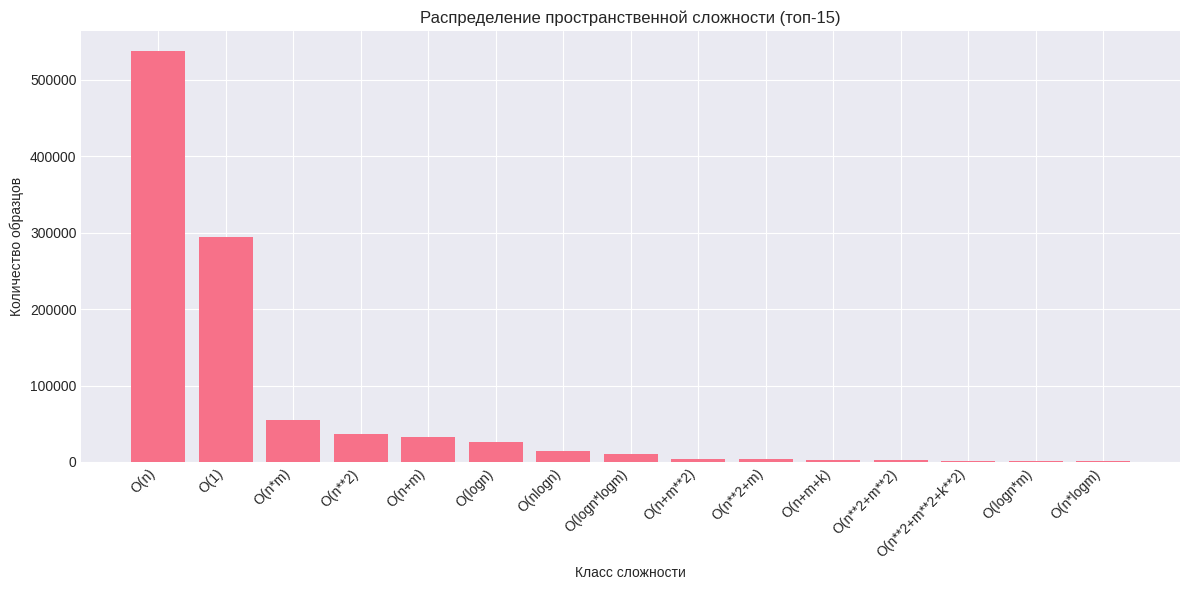

In [7]:
space_dist = Counter(s['space_complexity'] for s in all_data)

top_space = space_dist.most_common(15)

df_space = pd.DataFrame(top_space, columns=['Класс', 'Количество'])
df_space['Процент'] = (df_space['Количество'] / len(all_data) * 100).round(2)

print("ТОП-15 КЛАССОВ ПРОСТРАНСТВЕННОЙ СЛОЖНОСТИ")
print(df_space.to_string(index=False))

# Визуализация
plt.figure(figsize=(12, 6))
plt.bar(range(len(df_space)), df_space['Количество'])
plt.xticks(range(len(df_space)), df_space['Класс'], rotation=45, ha='right')
plt.xlabel('Класс сложности')
plt.ylabel('Количество образцов')
plt.title('Распределение пространственной сложности (топ-15)')
plt.tight_layout()
plt.show()

             Класс  Количество   Процент
37  O(logn*m*logk)         138  0.013319
38      O(n+m+k+l)         120  0.011582
39     O((n**2)+m)         117  0.011293
40     O(n*m*logk)         117  0.011293
41     O(n**2*m*k)         107  0.010327
42     O(n*m**2*k)          96  0.009266
43     O(n*m*k**2)          88  0.008494
44      O(n*m*k*l)          41  0.003957


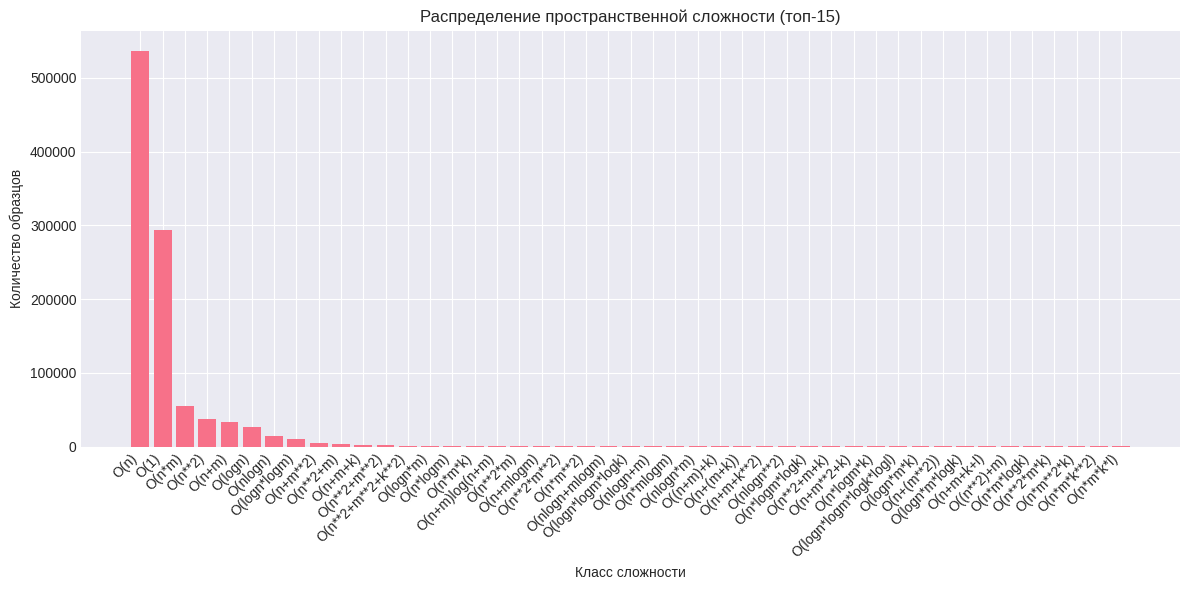

In [17]:
space_dist = Counter(s['space_complexity'] for s in all_data)

top_space = space_dist.most_common(1500)

df_space = pd.DataFrame(top_space, columns=['Класс', 'Количество'])
df_space['Процент'] = (df_space['Количество'] / len(all_data) * 100)#.round(2)

df_space_rare = df_space[df_space['Количество'] < 150]
print(df_space_rare)

# Визуализация
plt.figure(figsize=(12, 6))
plt.bar(range(len(df_space)), df_space['Количество'])
plt.xticks(range(len(df_space)), df_space['Класс'], rotation=45, ha='right')
plt.xlabel('Класс сложности')
plt.ylabel('Количество образцов')
plt.title('Распределение пространственной сложности (топ-15)')
plt.tight_layout()
plt.show()

In [8]:
# Топ-20 пар
time_space_pairs = Counter(
    (s['time_complexity'], s['space_complexity']) 
    for s in all_data
)

top_pairs = time_space_pairs.most_common(20)

df_pairs = pd.DataFrame(
    [(t, s, c, c/len(all_data)*100) for (t, s), c in top_pairs],
    columns=['Временная', 'Пространственная', 'Количество', 'Процент']
)
df_pairs['Процент'] = df_pairs['Процент'].round(2)

print("ТОП-20 ПАР (ВРЕМЯ, ПАМЯТЬ)")
print(df_pairs.to_string(index=False))

ТОП-20 ПАР (ВРЕМЯ, ПАМЯТЬ)
 Временная Пространственная  Количество  Процент
      O(n)             O(n)      328719    31.73
      O(1)             O(1)      174398    16.83
      O(n)             O(1)       79135     7.64
  O(nlogn)             O(n)       78020     7.53
   O(n**2)             O(n)       42322     4.08
    O(n*m)           O(n*m)       34980     3.38
      O(1)             O(n)       25787     2.49
   O(n**2)          O(n**2)       20887     2.02
      O(1)          O(logn)       16652     1.61
    O(n*m)             O(n)       15444     1.49
    O(n+m)             O(n)       14443     1.39
    O(n+m)           O(n+m)       13854     1.34
   O(logn)             O(1)       11817     1.14
O(n+mlogm)             O(n)        8985     0.87
  O(nlogn)             O(1)        8877     0.86
      O(1)     O(logn*logm)        8361     0.81
O(nlogn+m)             O(n)        7915     0.76
   O(n**2)             O(1)        7890     0.76
      O(n)          O(n**2)        6944   

/tmp/ipykernel_64672/965003305.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


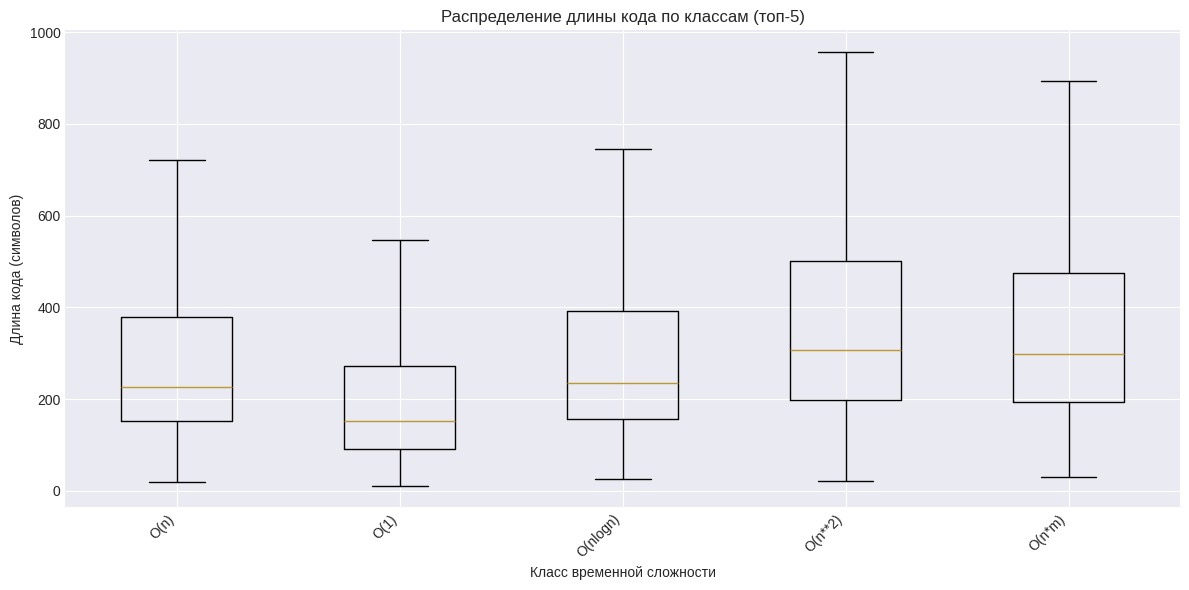


O(n):
  Медиана: 227
  Средняя: 366

O(1):
  Медиана: 152
  Средняя: 291

O(nlogn):
  Медиана: 235
  Средняя: 377

O(n**2):
  Медиана: 307
  Средняя: 464

O(n*m):
  Медиана: 298
  Средняя: 444


In [9]:
# Анализ для топ-5 временных классов
top_5_time = [cls for cls, _ in time_dist.most_common(5)]

code_by_class = {}
for cls in top_5_time:
    lengths = [len(s['code']) for s in all_data if s['time_complexity'] == cls]
    code_by_class[cls] = lengths

# Boxplot
plt.figure(figsize=(12, 6))
plt.boxplot(
    [code_by_class[cls] for cls in top_5_time],
    labels=top_5_time,
    showfliers=False  # Скрываем выбросы для читаемости
)
plt.ylabel('Длина кода (символов)')
plt.xlabel('Класс временной сложности')
plt.title('Распределение длины кода по классам (топ-5)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Статистика
for cls in top_5_time:
    lengths = code_by_class[cls]
    print(f"\n{cls}:")
    print(f"  Медиана: {sorted(lengths)[len(lengths)//2]:,}")
    print(f"  Средняя: {sum(lengths)/len(lengths):,.0f}")

БАЛАНС ПО SPLITS
Split          Образцов    Time классов   Space классов
------------------------------------------------------------
Train           732,351              47              45
Val             159,857              47              40
Test            143,876              47              44


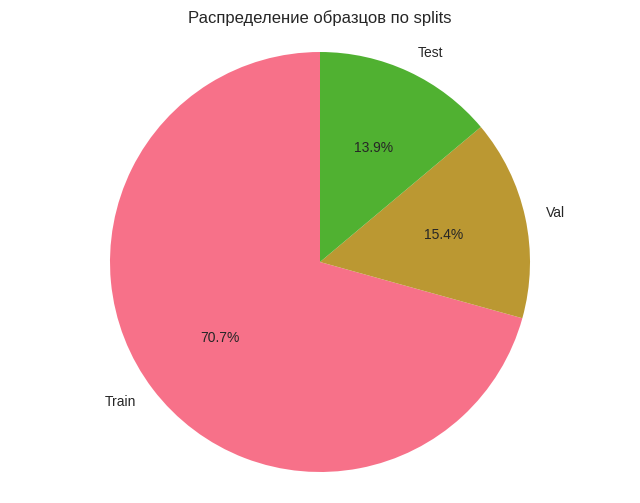

In [10]:
def analyze_split(data, name):
    """Анализ одного split"""
    time_dist = Counter(s['time_complexity'] for s in data)
    space_dist = Counter(s['space_complexity'] for s in data)
    
    return {
        'name': name,
        'samples': len(data),
        'time_classes': len(time_dist),
        'space_classes': len(space_dist),
        'top_time': time_dist.most_common(3)
    }

split_stats = [
    analyze_split(train_data, 'Train'),
    analyze_split(val_data, 'Val'),
    analyze_split(test_data, 'Test')
]

print("БАЛАНС ПО SPLITS")
print(f"{'Split':<10} {'Образцов':>12} {'Time классов':>15} {'Space классов':>15}")
print("-" * 60)
for stat in split_stats:
    print(f"{stat['name']:<10} {stat['samples']:>12,} {stat['time_classes']:>15} {stat['space_classes']:>15}")

# Визуализация размеров splits
plt.figure(figsize=(8, 6))
sizes = [s['samples'] for s in split_stats]
labels = [s['name'] for s in split_stats]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Распределение образцов по splits')
plt.axis('equal')
plt.show()

In [11]:
import random

print("ПРИМЕРЫ ОБРАЗЦОВ\n")

for i, sample in enumerate(random.sample(all_data, 3), 1):
    print(f"{'='*60}")
    print(f"Пример {i}")
    print(f"{'='*60}")
    print(f"Problem ID: {sample['problem_id']}")
    print(f"Problem Name: {sample['problem_name']}")
    print(f"Time Complexity: {sample['time_complexity']}")
    print(f"Space Complexity: {sample['space_complexity']}")
    print(f"\nКод ({len(sample['code'])} символов):")
    print("-" * 60)
    print(sample['code'][:500])  # Первые 500 символов
    if len(sample['code']) > 500:
        print("...")
    print()

ПРИМЕРЫ ОБРАЗЦОВ

Пример 1
Problem ID: 2359
Problem Name: 962_A. Equator
Time Complexity: O(n)
Space Complexity: O(n)

Код (2741 символов):
------------------------------------------------------------
#_______________________________________________________________#
def fact(x):
	if x == 0:
		return 1
	else:
		return x * fact(x-1)
def lower_bound(li, num): 
	answer = -1
	start = 0
	end = len(li)-1

	while(start <= end):
		middle = (end+start)//2
		if li[middle] >= num:
			answer = middle
			end = middle - 1
		else:
			start = middle + 1
	return answer #index where x is not less than num
def upper_bound(li, num): 
	answer = -1
	start = 0
	end = len(li)-1

	while(start <= end):
		middle = (end+
...

Пример 2
Problem ID: 2142
Problem Name: 727_B. Bill Total Value
Time Complexity: O(n)
Space Complexity: O(1)

Код (915 символов):
------------------------------------------------------------
def num(a):
    if len(a) < 4:
        return int(a) * 100
    q = 1
    if a[-3] != '.':
        q = 

In [14]:
report = {
    'total_samples': len(all_data),
    'unique_problems': unique_problems,
    'splits': {
        'train': len(train_data),
        'val': len(val_data),
        'test': len(test_data)
    },
    'complexity_classes': {
        'time': unique_time_classes,
        'space': unique_space_classes
    },
    'top_time_classes': [(cls, count) for cls, count in time_dist.most_common(10)],
    'top_space_classes': [(cls, count) for cls, count in space_dist.most_common(10)],
    'code_length': {
        'min': min(code_lengths),
        'median': sorted(code_lengths)[len(code_lengths)//2],
        'max': max(code_lengths),
        'mean': sum(code_lengths) / len(code_lengths)
    }
}
# Сохранение отчета
report_path = Path("../data/bigobench/analysis_report_v1.json")
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print(f"Отчет сохранен в {report_path}")

Отчет сохранен в ../data/bigobench/analysis_report_v1.json


In [13]:
print(f"{'='*60}")
print("ВЫВОДЫ")
print(f"{'='*60}\n")

top_3_time = time_dist.most_common(3)
top_3_space = space_dist.most_common(3)

print(f"1. Доминирующие классы временной сложности:")
for cls, count in top_3_time:
    pct = count / len(all_data) * 100
    print(f"   - {cls}: {count:,} ({pct:.1f}%)")

print(f"\n2. Доминирующие классы пространственной сложности:")
for cls, count in top_3_space:
    pct = count / len(all_data) * 100
    print(f"   - {cls}: {count:,} ({pct:.1f}%)")

print(f"\n3. Баланс датасета:")
imbalance_ratio = max(time_dist.values()) / min(time_dist.values())
print(f"   - Дисбаланс классов (макс/мин): {imbalance_ratio:.1f}x")
print(f"   - Рекомендация: {'Использовать взвешенную loss функцию' if imbalance_ratio > 10 else 'Баланс приемлемый'}")

print(f"\n4. Качество splits:")
train_ratio = len(train_data) / len(all_data)
val_ratio = len(val_data) / len(all_data)
test_ratio = len(test_data) / len(all_data)
print(f"   - Train/Val/Test: {train_ratio:.1%}/{val_ratio:.1%}/{test_ratio:.1%}")

print(f"\n{'='*60}")

ВЫВОДЫ

1. Доминирующие классы временной сложности:
   - O(n): 432,302 (41.7%)
   - O(1): 231,690 (22.4%)
   - O(nlogn): 105,267 (10.2%)

2. Доминирующие классы пространственной сложности:
   - O(n): 537,109 (51.8%)
   - O(1): 294,415 (28.4%)
   - O(n*m): 55,392 (5.3%)

3. Баланс датасета:
   - Дисбаланс классов (макс/мин): 4456.7x
   - Рекомендация: Использовать взвешенную loss функцию

4. Качество splits:
   - Train/Val/Test: 70.7%/15.4%/13.9%

